In [1]:

import pandas as pd
import numpy as np

In [5]:
from google.colab import files

uploaded = files.upload()

Saving banknote+authentication (1).zip to banknote+authentication (1) (1).zip


In [9]:
import os

print(os.getcwd())      # Shows current folder
print(os.listdir())     # Shows files in current folder

/content
['.config', 'banknote+authentication (1).zip', 'banknote+authentication (1) (1).zip', 'sample_data']


In [13]:
import zipfile

with zipfile.ZipFile("banknote+authentication (1).zip", "r") as zip_ref:
    zip_ref.extractall()

import os
print(os.listdir())

['.config', 'banknote+authentication (1).zip', 'data_banknote_authentication.txt', 'banknote+authentication (1) (1).zip', 'sample_data']


In [14]:
column_names = ["Variance","Skewness","Curtosis","Entropy","Class"]

df = pd.read_csv("data_banknote_authentication.txt",header=None,names=column_names)

df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [15]:
print("Dataset Shape:")
print(df.shape)
print()
print("Total Rows Present :", df.shape[0])
print("Total Columns Pesent :", df.shape[1])

Dataset Shape:
(1372, 5)

Total Rows Present : 1372
Total Columns Pesent : 5


In [ ]:
print(df.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [16]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


TASK 2

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look better
sns.set(style="whitegrid")

# Display plots inside Colab
%matplotlib inline

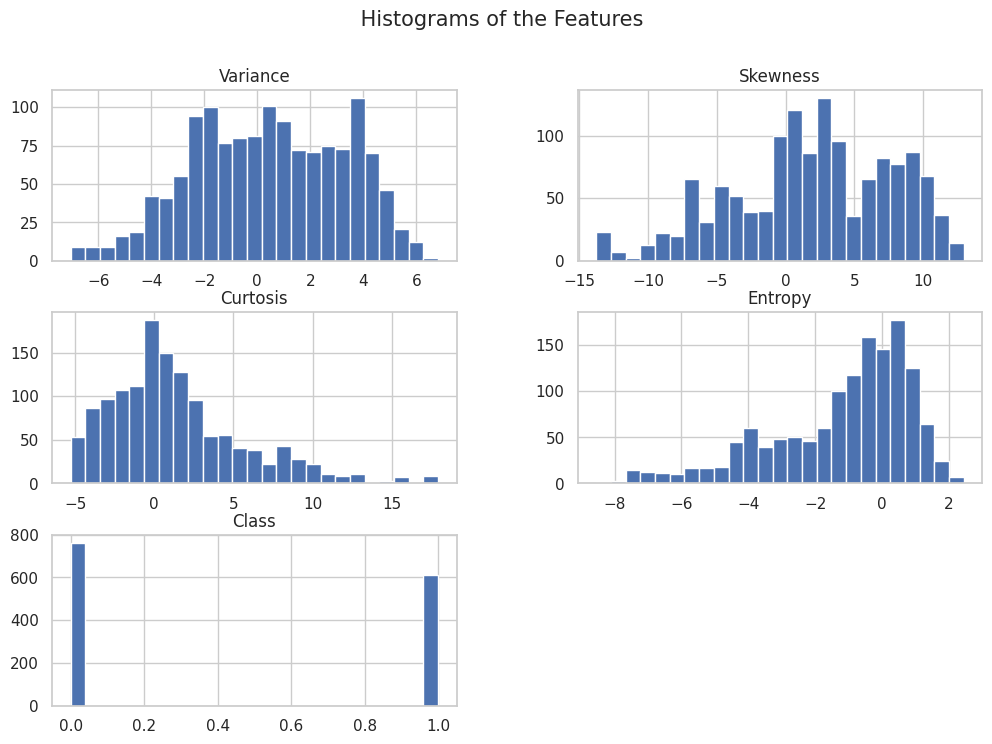

In [ ]:
df.hist(figsize=(12,8), bins=25)
plt.suptitle(" Histograms of the Features ", fontsize=15)
plt.savefig("correlation_heatmap.eps",dpi=600, format="eps")
plt.show()

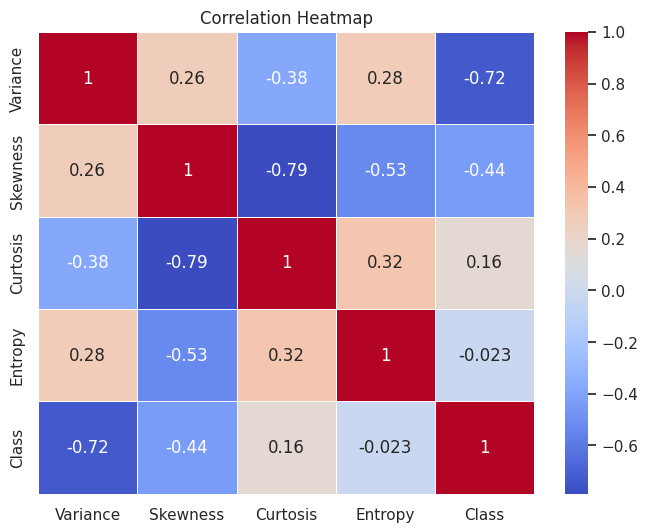

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm",linewidths=0.5)
plt.savefig("correlation_heatmap.eps",dpi=600, format="eps")

plt.title("Correlation Heatmap")
plt.show()

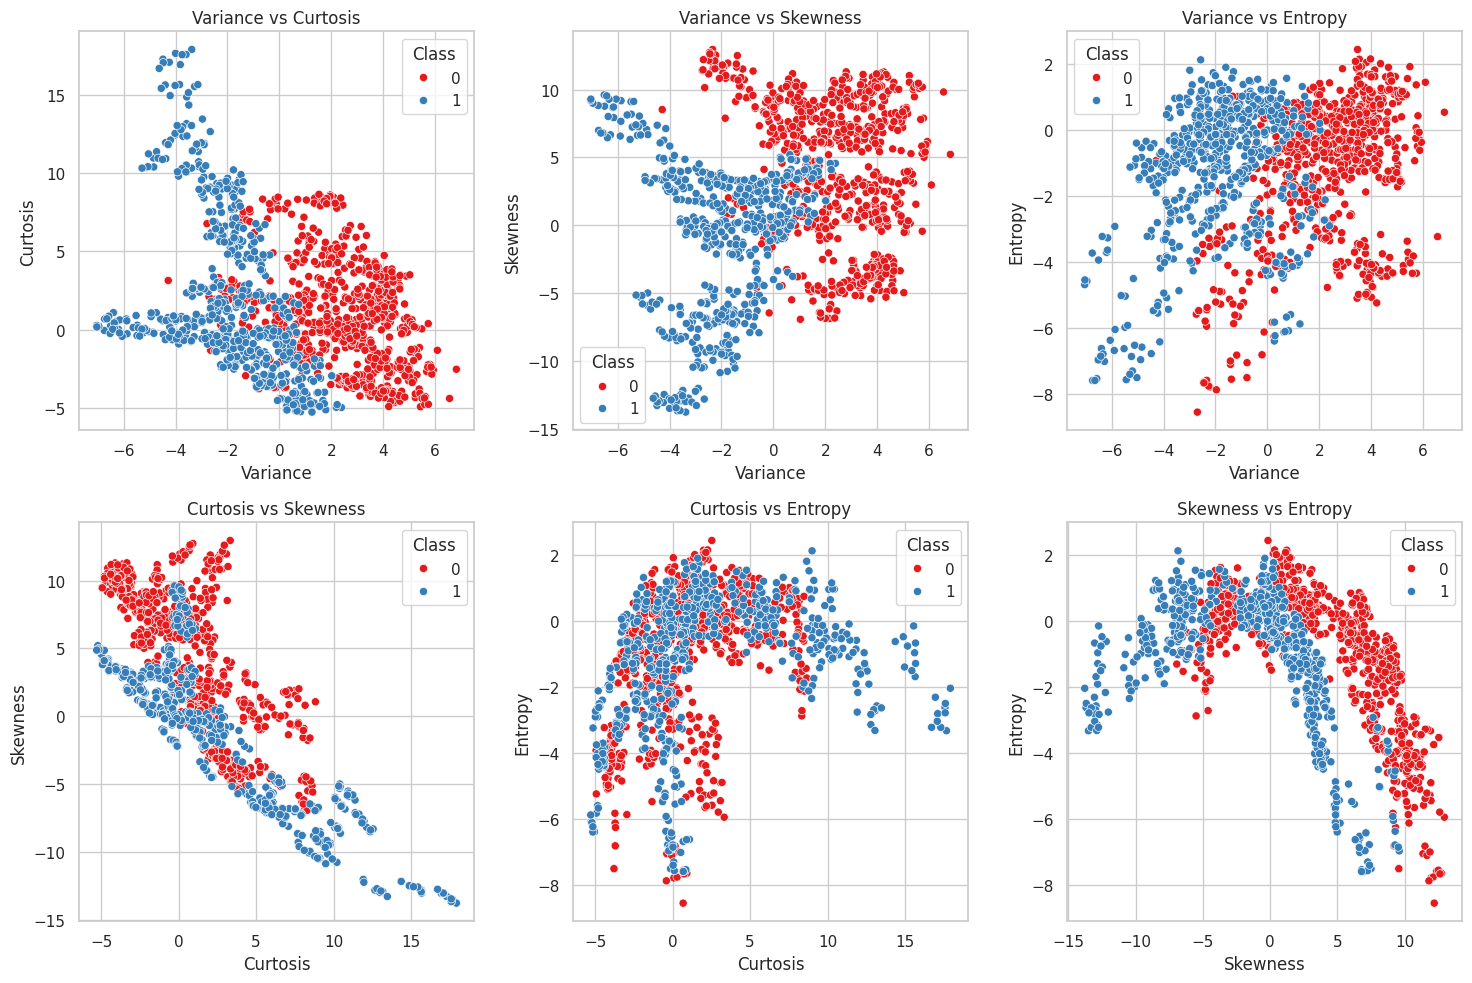

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

features = ["Variance",  "Curtosis","Skewness","Entropy"]

pairs = list(combinations(features, 2))

plt.figure(figsize=(15, 10))

for i, (x, y) in enumerate(pairs):
    plt.subplot(2, 3, i + 1)

    sns.scatterplot(
        data=df,
        x=x,
        y=y,
        hue="Class",
        palette="Set1",
        s=35
    )

    plt.title(f"{x} vs {y}")
plt.savefig("correlation_heatmap.eps",dpi=600, format="eps")
plt.tight_layout()
plt.show()

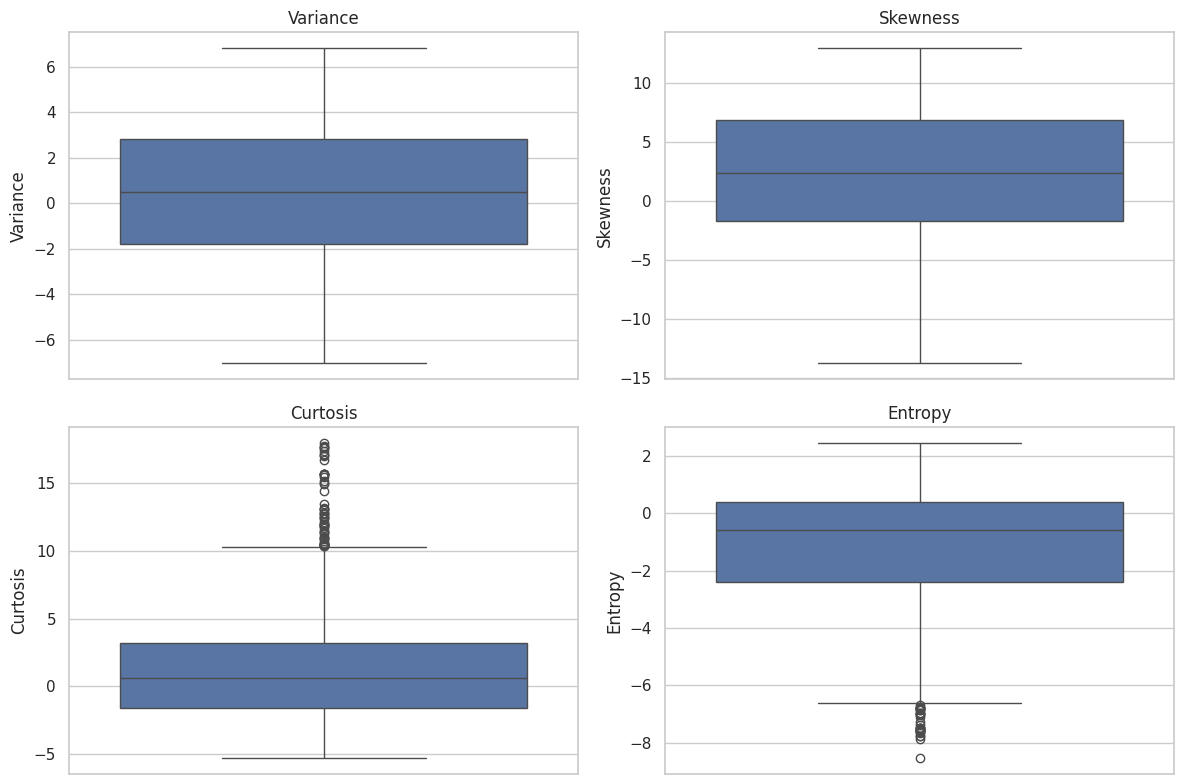

In [ ]:
plt.figure(figsize=(12,8))
plt.savefig("correlation_heatmap.eps",dpi=600, format="eps")

for i, column in enumerate(df.columns[:-1]):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

BOX PLOT

TASK 3

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Features (X) and Target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

print("The shape of feature matrix :", X.shape)
print("the shape of Target matrix:", y.shape)

The shape of feature matrix : (1372, 4)
the shape of Target matrix: (1372,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 1097
Testing Samples  : 275


In [ ]:
scaler = StandardScaler()

# Fit only on training data
X_train = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test = scaler.transform(X_test)
print("First Five Normalized Training Samples:\n")

print(X_train[:5])

First Five Normalized Training Samples:

[[ 0.39687699  0.05746643 -1.03953765  0.51951506]
 [-0.38173115 -0.22255311 -0.41215984  0.26034815]
 [ 1.25707446 -0.2779253  -0.11902626  1.13526037]
 [-0.10891208 -0.29720014 -0.70982581  0.85710298]
 [-1.1841959  -0.41950842  0.27444212  1.22779629]]


In [ ]:
print("Training the Feature Shape :", X_train.shape)
print("Testing the Feature Shape  :", X_test.shape)

print("Training the Labels Shape  :", y_train.shape)
print("Testing the Labels Shape   :", y_test.shape)

Training the Feature Shape : (1097, 4)
Testing the Feature Shape  : (275, 4)
Training the Labels Shape  : (1097,)
Testing the Labels Shape   : (275,)


TASK 4

In [ ]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0

    def activation(self, z):
        if z >= 0:
            return 1
        else:
            return 0

    def predict_single(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation(z)

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.initialize_parameters(n_features)

        self.errors = []
        self.weight_history = []
        self.bias_history = []

        for epoch in range(self.epochs):

            errors = 0

            for i in range(n_samples):

                prediction = self.predict_single(X[i])

                update = self.learning_rate * (y.iloc[i] - prediction)

                self.weights += update * X[i]
                self.bias += update

                if update != 0:
                    errors += 1

            self.errors.append(errors)
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            print(f"Epoch {epoch+1}")
            print("Misclassified Samples:", errors)
            print("Weights:", self.weights)
            print("Bias:", self.bias)
            print("-"*50)

    def predict(self, X):

        predictions = []

        for sample in X:
            predictions.append(self.predict_single(sample))

        return np.array(predictions)

In [ ]:
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

TASK 5

In [ ]:
# Create the perceptron model
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)


In [ ]:
model.fit(X_train, y_train)

Epoch 1
Misclassified Samples: 51
Weights: [-0.06024909 -0.08407687 -0.06300015  0.00226864]
Bias: -0.03
--------------------------------------------------
Epoch 2
Misclassified Samples: 32
Weights: [-0.08625065 -0.10215292 -0.07663789  0.0073922 ]
Bias: -0.03
--------------------------------------------------
Epoch 3
Misclassified Samples: 27
Weights: [-0.09932445 -0.11330756 -0.08197553  0.00545098]
Bias: -0.04
--------------------------------------------------
Epoch 4
Misclassified Samples: 25
Weights: [-0.07988243 -0.11840653 -0.10632953 -0.00732292]
Bias: -0.05
--------------------------------------------------
Epoch 5
Misclassified Samples: 27
Weights: [-0.10986763 -0.1248832  -0.1030505  -0.00681503]
Bias: -0.04
--------------------------------------------------
Epoch 6
Misclassified Samples: 20
Weights: [-0.10451397 -0.12636185 -0.11458703  0.01092347]
Bias: -0.060000000000000005
--------------------------------------------------
Epoch 7
Misclassified Samples: 20
Weights: [-0.1

In [ ]:
print("Final Weights:")
print(model.weights)

print("\nFinal Bias:")
print(model.bias)

Final Weights:
[-0.14492063 -0.19690367 -0.17347459 -0.02116243]

Final Bias:
-0.08


In [ ]:
print("values of the errors in Each Epoch:")

for epoch, error in enumerate(model.errors, start=1):
    print(f"Epoch {epoch}: {error}")

values of the errors in Each Epoch:
Epoch 1: 51
Epoch 2: 32
Epoch 3: 27
Epoch 4: 25
Epoch 5: 27
Epoch 6: 20
Epoch 7: 20
Epoch 8: 23
Epoch 9: 21
Epoch 10: 22
Epoch 11: 18
Epoch 12: 20
Epoch 13: 22
Epoch 14: 26
Epoch 15: 19
Epoch 16: 18
Epoch 17: 24
Epoch 18: 17
Epoch 19: 17
Epoch 20: 15


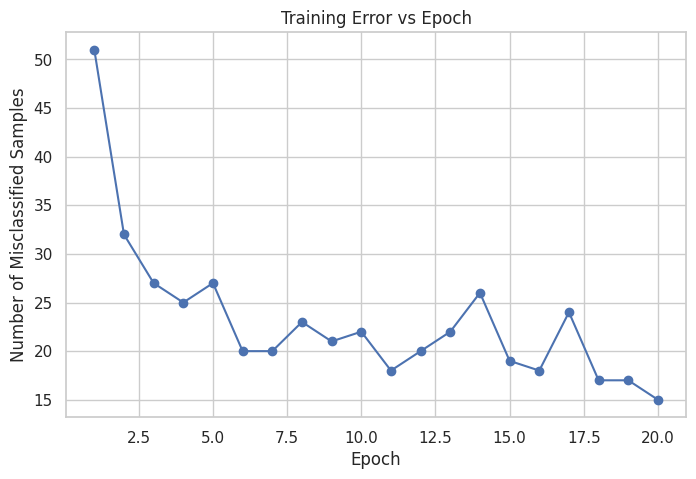

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, model.epochs + 1),
    model.errors,
    marker='o'
)

plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.grid(True)

plt.show()

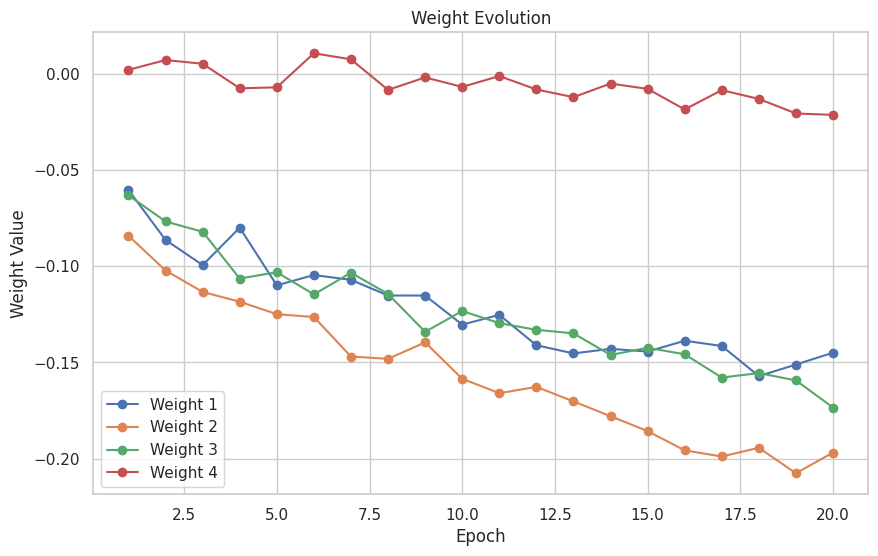

In [ ]:
weights = np.array(model.weight_history)

plt.figure(figsize=(10,6))

for i in range(weights.shape[1]):
    plt.plot(
        range(1, model.epochs + 1),
        weights[:, i],
        marker='o',
        label=f'Weight {i+1}'
    )

plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")

plt.legend()
plt.grid(True)


plt.show()

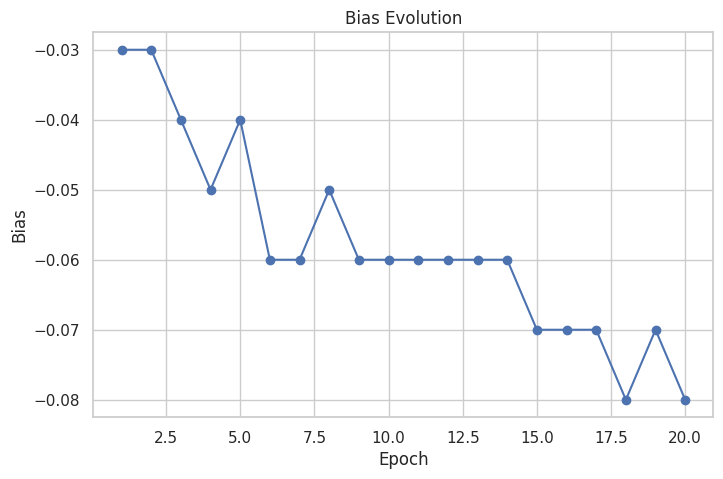

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1, model.epochs + 1),model.bias_history,marker='o')

plt.title("Bias Evolution Graph")
plt.xlabel("Epoch")
plt.ylabel("Bias")

plt.grid(True)

plt.show()

In [ ]:
epoch_table = pd.DataFrame({
    "Epoch": range(1, model.epochs + 1),
    "Errors": model.errors,
    "Bias": model.bias_history
})

epoch_table

,Epoch,Errors,Bias
0,1,51,-0.03
1,2,32,-0.03
2,3,27,-0.04
3,4,25,-0.05
4,5,27,-0.04
5,6,20,-0.06
6,7,20,-0.06
7,8,23,-0.05
8,9,21,-0.06
9,10,22,-0.06


In [ ]:
weights_df = pd.DataFrame(
    model.weight_history,
    columns=[
        "Weight 1",
        "Weight 2",
        "Weight 3",
        "Weight 4"
    ]
)

training_summary = pd.concat(
    [epoch_table, weights_df],
    axis=1
)

training_summary

,Epoch,Errors,Bias,Weight 1,Weight 2,Weight 3,Weight 4
0,1,51,-0.03,-0.060249,-0.084077,-0.063000,0.002269
1,2,32,-0.03,-0.086251,-0.102153,-0.076638,0.007392
2,3,27,-0.04,-0.099324,-0.113308,-0.081976,0.005451
3,4,25,-0.05,-0.079882,-0.118407,-0.106330,-0.007323
4,5,27,-0.04,-0.109868,-0.124883,-0.103051,-0.006815
5,6,20,-0.06,-0.104514,-0.126362,-0.114587,0.010923
6,7,20,-0.06,-0.107017,-0.146926,-0.103330,0.007750
7,8,23,-0.05,-0.115165,-0.148132,-0.114359,-0.008150
8,9,21,-0.06,-0.115194,-0.139570,-0.134084,-0.001655
9,10,22,-0.06,-0.130326,-0.158487,-0.123270,-0.006587


TASK 6

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Performance
------------------------
Accuracy : 0.9855
Precision: 0.9683
Recall   : 1.0000
F1-Score : 0.9839


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[149   4]
 [  0 122]]


<Figure size 600x600 with 0 Axes>

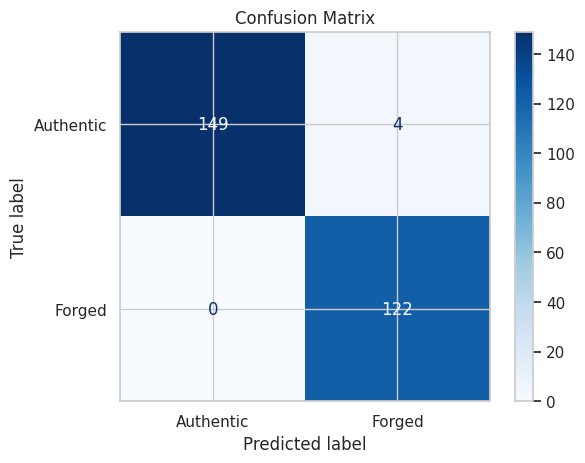

In [ ]:
plt.figure(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Authentic", "Forged"]
)

disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix")
plt.show()